# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lê Huy Hồng Nhật"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600099"     # <-- Điền MSSV của bạn

from IPython.display import display, HTML


def display_student_header(section_title=None):
    """Hiển thị header thông tin sinh viên ở đầu output của cell hiện tại."""
    section_html = f"<div style='font-size: 14px; margin-top: 6px;'>Section: <strong>{section_title}</strong></div>" if section_title else ""
    header = f"""
    <div style="background: linear-gradient(90deg, #1f7a5c 0%, #124f7a 100%);
                color: white; padding: 12px 14px; border-radius: 10px;
                margin: 8px 0 12px 0; font-family: Arial, sans-serif;
                box-shadow: 0 2px 8px rgba(0,0,0,0.18);">
        <h2 style="margin: 0; color: white; font-size: 20px;">GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 15px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} |
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
        {section_html}
    </div>
    """
    display(HTML(header))


def install_student_sticky_header():
    """Tạo banner cố định trên trang notebook nếu frontend cho phép custom HTML/CSS."""
    display(HTML(f"""
    <style>
      #gpu-finops-student-sticky {{
        position: sticky;
        top: 0;
        z-index: 9999;
        background: linear-gradient(90deg, #1f7a5c 0%, #124f7a 100%);
        color: #fff;
        padding: 8px 12px;
        border-radius: 8px;
        margin: 4px 0 10px 0;
        font-family: Arial, sans-serif;
        box-shadow: 0 2px 8px rgba(0,0,0,0.18);
      }}
    </style>
    <div id="gpu-finops-student-sticky">
      <strong>GPU FinOps Lab</strong> | {STUDENT_NAME} | {STUDENT_ID}
    </div>
    """))


print("=" * 60)
print("QUAN TRONG: Hay nhap dung thong tin sinh vien o STUDENT_NAME va STUDENT_ID.")
print("Header se duoc hien thi lai o dau moi code cell de chup screenshot de hon.")
print("=" * 60)
install_student_sticky_header()
display_student_header("Student Information Setup")

QUAN TRONG: Hay nhap dung thong tin sinh vien o STUDENT_NAME va STUDENT_ID.
Header se duoc hien thi lai o dau moi code cell de chup screenshot de hon.


In [3]:
display_student_header('Cell 2: Configure Gateway URL')
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://wires-lifestyle-trio-substantially.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
display_student_header('Cell 3: View Cluster Nodes')
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 9 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 93.7% | Mem: 10.0/16.0GB | Power: 61W | Temp: 55°C
   GPU 1 [T4] 🔴 Util: 92.6% | Mem: 10.2/16.0GB | Power: 55W | Temp: 60°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 81.6% | Mem: 55.7/80.0GB | Power: 234W | Temp: 61°C
   GPU 1 [A100] 🔴 Util: 87.3% | Mem: 67.9/80.0GB | Power: 279W | Temp: 74°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 72.1% | Mem: 17.6/32.0GB | Power: 213W | Temp: 70°C
   GPU 1 [V100] 🟢 Util: 4.6% | Mem: 1.5/32.0GB | Power: 49W | Temp: 45°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 73.9% | Mem: 8.7/16.0GB | Power: 60W | Temp: 69°C
   GPU 1 [T4] 🔴 Util: 76.8% | Mem: 12.5/16.0GB | Power: 61W | Temp: 67°C

🖥️  node-04:
   GPU 0 [T4] 🔴 Util: 66.4% | Mem: 11.5/16.0GB | Power: 58W | Temp: 65°C
   GPU 1 [T4] 🔴 Util: 81.6% | Mem: 10.7/16.0GB | Power: 58W | Temp: 61°C

🖥️  node-05:
   GPU 0 [T4] 🔴 Util: 69.1% | Mem: 10.7/16.0GB | Power: 54W | Temp: 55°C
   GPU 1 [T4] 🔴 Util: 67.1% | Mem: 12.4/16.0GB | Power: 45W | Temp: 62°C

🖥️  node-

In [5]:
display_student_header('Cell 4: Cluster Metrics Summary')
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          18
Busy GPUs:           13
Idle GPUs:           5
Avg Utilization:     56.7%
Memory Used:         252.1 GB
Memory Capacity:     448.0 GB
Total Power Draw:    1417 W
Node Count:          9


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
display_student_header('Cell 5: Submit multiple workloads')
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-07', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-07', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-08', 'gpu_id': 0}, {'node_id': 'node-08', 'gpu_id': 1}]

📊 Updated metrics:
   Busy GPUs: 18/18 | Utilization: 79.2%


In [7]:
display_student_header('Cell 6: Record billing for workloads')
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $5.2869
   Total Savings:  $5.5380
   Budget Used:    5.3%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
display_student_header('Cell 7: Check spot pricing')
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2500     28.6    % medium
A100       $3.67       $2.8853     21.4    % low
V100       $2.48       $1.5778     36.4    % high


In [9]:
display_student_header('Cell 8: Request spot instances')
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
display_student_header('Cell 9: Simulate spot preemption')
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 5

   ⚠️  Preempted:
      - spot-t4-001 (ran for 1s, 60s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0167
   On-demand equiv:  $0.0557
   Total saved:      $0.0390 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
display_student_header('Cell 10: View and update autoscaling policy')
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
display_student_header('Cell 11: Trigger autoscaler evaluation')
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 79.2% > threshold 70.0%
   Current utilization: 79.2%
   Nodes: 9 → 10

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 71.3% | Nodes: 10→10
   Cycle 2: no_action    | Util: 71.3% | Nodes: 10→10
   Cycle 3: no_action    | Util: 71.3% | Nodes: 10→10
   Cycle 4: no_action    | Util: 71.3% | Nodes: 10→10
   Cycle 5: no_action    | Util: 71.3% | Nodes: 10→10


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
display_student_header('Cell 12: Take cost snapshots')
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 2: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 3: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 4: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%
   Snapshot 5: Total=$0.049722 | Idle=$0.001944 | Waste=3.9%


In [14]:
display_student_header('Cell 13: Waste Report')
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.1%
   Total Idle Cost:        $0.019440
   Total Cost:             $0.479720
   Potential Monthly Save:  $503.88
   Severity:               LOW


In [15]:
display_student_header('Cell 14: Get Optimization Recommendations')
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
display_student_header('Cell 15: Full Dashboard View')
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 20 GPUs across 10 nodes
   Utilization: 71.3% | Busy: 18 | Idle: 2

💰 BILLING: $5.2869 / $100.00 budget
   Alert: OK | Savings: $5.5380

🎯 SPOT: Saved $0.0598 (70.0%)

🗑️  WASTE: 4.1% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

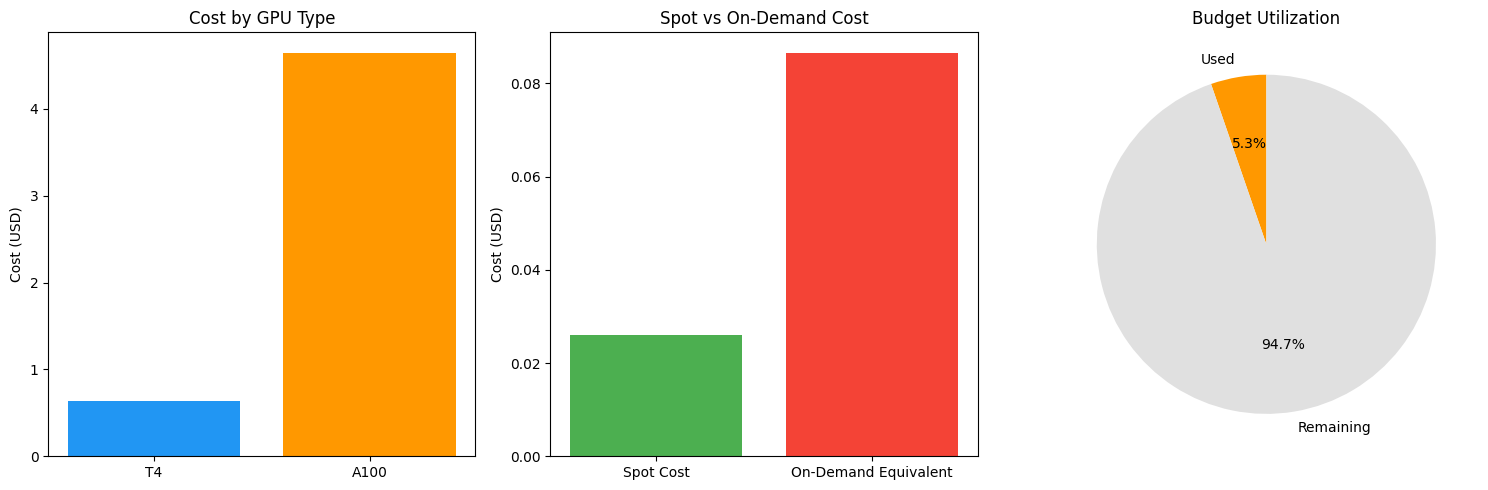

📊 Chart saved as finops_cost_breakdown.png


In [17]:
display_student_header('Cell 16: Cost Breakdown Visualization')
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


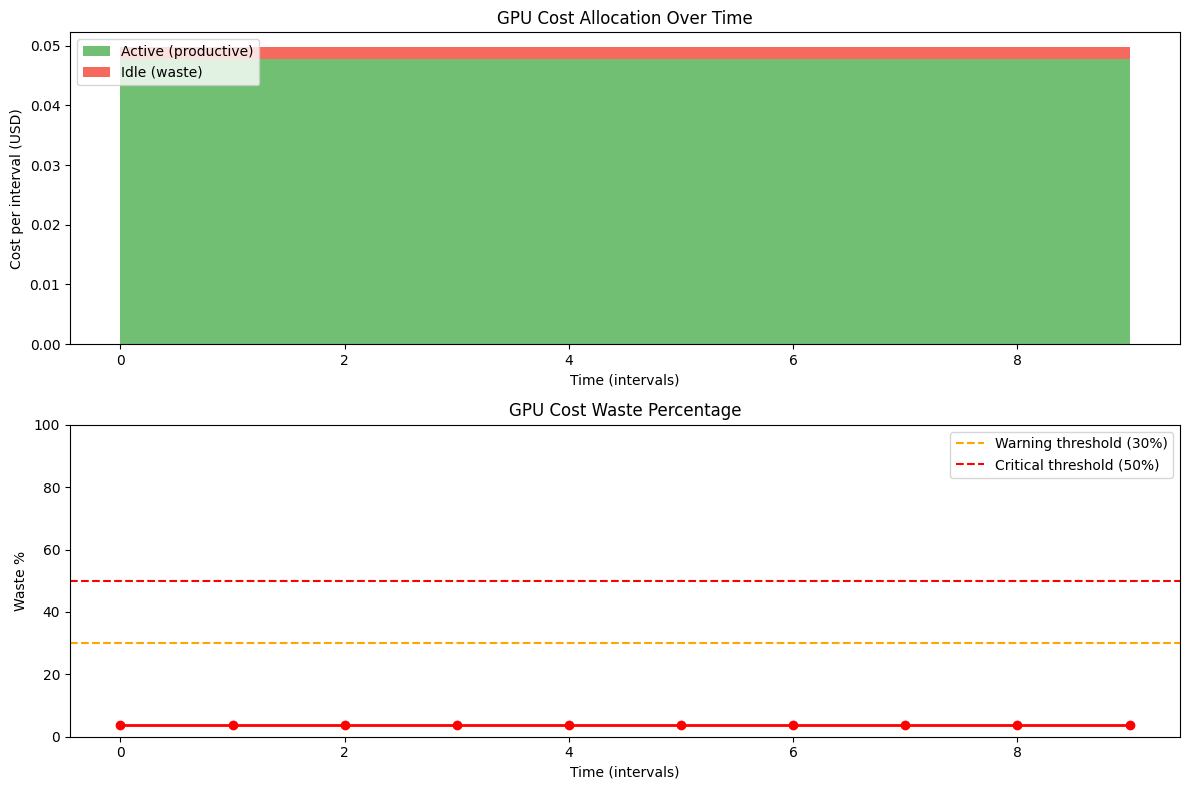

In [18]:
display_student_header('Cell 17: Time-series cost tracking')
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
display_student_header('Cell 18: Full FinOps Optimization Workflow')
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 20 | Util: 71.3% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 79.6% | Busy: 20/20

3️⃣  Autoscaler evaluation:
   Decision: no_action - Utilization 79.6% within thresholds [25.0-70.0%]

4️⃣  Cost analysis:
   Total cost/interval: $0.049722
   Waste: 0.0%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0333 (70.0%)

7️⃣  Final billing:
   Total spend: $5.4560
   Total saved: $5.6604
   Budget: 5.5% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
display_student_header('Cell 19: Install dependencies & detect real GPU')
# Cell 19: Install dependencies & detect real GPU

# Kaggle/Colab usually already provides torch/torchvision. Avoid forcing an upgrade
# because a newer CUDA wheel may not support older GPUs such as P100.
!pip install -q pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from contextlib import nullcontext
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

REQUIRE_REAL_GPU = True
CUDA_USABLE = False
DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(DEVICE_TYPE)

if DEVICE_TYPE == "cuda":
    try:
        # torch.cuda.is_available() is not enough. This catches incompatible wheels
        # early, before the long training cells fail inside BatchNorm/Conv kernels.
        _probe = torch.randn(8, 3, 32, 32, device=DEVICE)
        _probe_model = nn.Conv2d(3, 4, kernel_size=3, padding=1).to(DEVICE)
        _probe_out = _probe_model(_probe)
        _probe_out.mean().backward()
        torch.cuda.synchronize()
        CUDA_USABLE = True
        del _probe, _probe_model, _probe_out
        torch.cuda.empty_cache()
    except Exception as e:
        CUDA_USABLE = False
        print("CUDA was detected but cannot execute PyTorch kernels.")
        print(f"Reason: {type(e).__name__}: {e}")
else:
    print("No CUDA GPU detected by PyTorch.")

if REQUIRE_REAL_GPU and not CUDA_USABLE:
    raise RuntimeError(
        "Real GPU training cannot continue because CUDA is not executable. "
        "On Kaggle/Colab, switch the accelerator to a T4/L4/A100 if available, then restart runtime and run from Cell 1. "
        "If you are on P100 and see 'no kernel image is available', the installed PyTorch CUDA wheel likely does not support that GPU. "
        "Use a T4 runtime or install a PyTorch build that supports the GPU before rerunning."
    )

# Detect GPU metadata after the execution probe passes.
gpu_name = torch.cuda.get_device_name(0)
gpu_props = torch.cuda.get_device_properties(0)
gpu_mem = gpu_props.total_memory / 1e9
compute_capability = f"{gpu_props.major}.{gpu_props.minor}"

# Map real GPU to pricing.
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81, "CPU": 0.0}
detected_type = "T4"
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print("Real GPU Detected and CUDA Probe Passed")
print(f"   Name:       {gpu_name}")
print(f"   Memory:     {gpu_mem:.1f} GB")
print(f"   Type:       {detected_type}")
print(f"   Compute:    {compute_capability}")
print(f"   Pricing:    ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   PyTorch:    {torch.__version__}")
print(f"   CUDA build: {torch.version.cuda}")
print(f"   Device:     {DEVICE}")
print(f"   pynvml:     {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected and CUDA Probe Passed
   Name:       Tesla T4
   Memory:     15.6 GB
   Type:       T4
   Compute:    7.5
   Pricing:    $0.35/hr (on-demand)
   PyTorch:    2.10.0+cu128
   CUDA build: 12.8
   Device:     cuda
   pynvml:     available


In [21]:
display_student_header('Cell 20: GPU Metrics Collection (works on Kaggle/Colab)')
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first, torch.cuda fallback. Assumes Cell 19 validated CUDA_USABLE.


def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""
    if DEVICE_TYPE != "cuda" or not CUDA_USABLE:
        return {
            'timestamp': time.time(),
            'gpu_util_pct': 0.0,
            'mem_util_pct': 0.0,
            'mem_used_mb': 0.0,
            'mem_total_mb': 0.0,
            'power_watts': 0.0,
            'temp_c': 0.0,
        }

    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception:
            pass

    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }


print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

print("\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\nReady for training on {DEVICE}.")


GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=2%, mem=602/16106 MB
   Power: 26.6W
   Temp: 38C

2. get_gpu_metrics() test:
   gpu_util_pct: 2.0
   mem_total_mb: 16106.12736
   mem_used_mb: 602.079232
   mem_util_pct: 0.0
   power_watts: 26.614
   temp_c: 38.0

Ready for training on cuda.


In [22]:
display_student_header('Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model')
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2, pin_memory=(DEVICE_TYPE == "cuda"))

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2, pin_memory=(DEVICE_TYPE == "cuda"))

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")
print(f"Training device: {DEVICE}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(DEVICE)


def amp_autocast(enabled):
    if enabled and DEVICE_TYPE == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def make_grad_scaler(enabled):
    if not enabled or DEVICE_TYPE != "cuda":
        return None
    try:
        return torch.amp.GradScaler("cuda")
    except Exception:
        return torch.cuda.amp.GradScaler()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = make_grad_scaler(use_amp)
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs = inputs.to(DEVICE, non_blocking=(DEVICE_TYPE == "cuda"))
        targets = targets.to(DEVICE, non_blocking=(DEVICE_TYPE == "cuda"))
        optimizer.zero_grad(set_to_none=True)

        if use_amp and scaler is not None:
            with amp_autocast(True):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        if batch_idx % sample_interval == 0:
            if DEVICE_TYPE == "cuda":
                torch.cuda.synchronize()
            metrics_samples.append(get_gpu_metrics())

    if DEVICE_TYPE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:03<00:00, 47.5MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Training device: cuda
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
display_student_header('Cell 22: Train FP32 (baseline) with inline GPU monitoring')
# Cell 22: Train FP32 (baseline) with inline GPU monitoring

NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

if REQUIRE_REAL_GPU and (DEVICE_TYPE != "cuda" or not CUDA_USABLE):
    raise RuntimeError("CUDA is not usable. Re-run Cell 19 after switching to a compatible GPU runtime.")

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

if DEVICE_TYPE == "cuda":
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9 if DEVICE_TYPE == "cuda" else 0.0
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\nTotal samples collected: {len(fp32_all_metrics)}")

fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print("\nFP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.7674 | Acc: 35.5% | Time: 38.3s | Samples: 40
   Epoch 2/3 | Loss: 1.1599 | Acc: 58.2% | Time: 38.9s | Samples: 40
   Epoch 3/3 | Loss: 0.8737 | Acc: 69.1% | Time: 40.0s | Samples: 40

Total samples collected: 120

FP32 Summary:
   Total time:      117.3s
   Peak memory:     0.82 GB
   Avg GPU util:    97.3%
   Avg power:       67.1W
   Avg temperature: 60.2C
   Max GPU util:    99.0%
   Estimated cost:  $0.011399


In [24]:
display_student_header('Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring')
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring

print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

if REQUIRE_REAL_GPU and (DEVICE_TYPE != "cuda" or not CUDA_USABLE):
    raise RuntimeError("CUDA is not usable. Re-run Cell 19 after switching to a compatible GPU runtime.")

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

if DEVICE_TYPE == "cuda":
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9 if DEVICE_TYPE == "cuda" else 0.0
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\nTotal samples collected: {len(amp_all_metrics)}")

amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print("\nAMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training
   Epoch 1/3 | Loss: 1.9033 | Acc: 31.4% | Time: 18.6s | Samples: 40
   Epoch 2/3 | Loss: 1.3370 | Acc: 51.0% | Time: 18.3s | Samples: 40
   Epoch 3/3 | Loss: 1.0238 | Acc: 63.6% | Time: 18.5s | Samples: 40

Total samples collected: 120

AMP Summary:
   Total time:      55.5s
   Peak memory:     0.60 GB
   Avg GPU util:    95.1%
   Avg power:       66.0W
   Avg temperature: 71.4C
   Max GPU util:    98.0%
   Estimated cost:  $0.005392


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                117.3           55.5            2.11x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.011399       $0.005392       $0.006007 saved
Cost Saving %             ---             ---             52.7%
Avg GPU Util %            97.3            95.1           
Avg Power (W)             67.1            66.0           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.97 -> SAVE $4.43
   1 week training: FP32=$58.80 vs AMP=$27.81 -> SAVE $30.99
   1 month training: FP32=$252.00 vs AMP=$119.20 -> SAVE $132.80


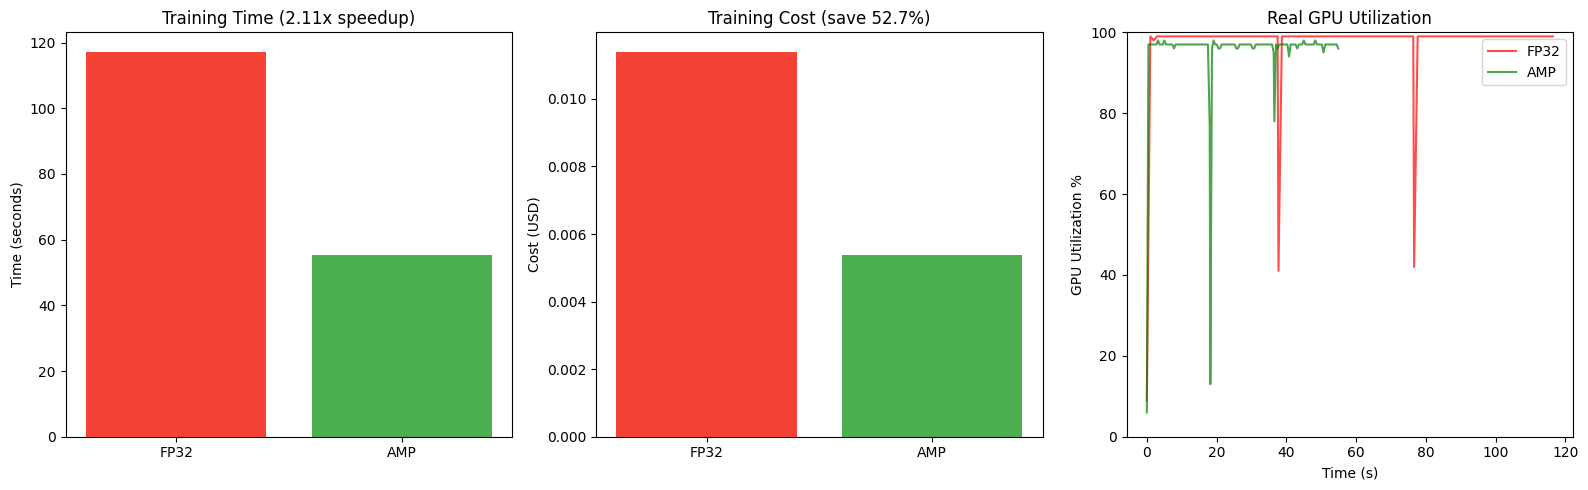

In [25]:
display_student_header('Cell 24: Compare FP32 vs AMP - FinOps Analysis')
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
display_student_header('Cell 25: Report real GPU costs back to the FinOps Gateway')
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.011400 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001600 | Saved: $0.003800

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.013000
   Total Savings:   $0.003800
   Workloads:       2

   Cost snapshot taken: waste=13.8%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $5.4560
   Total Savings:        $5.6604
   Budget Utilization:   5.5%
   Alert:                OK


Real GPU Telemetry During Training


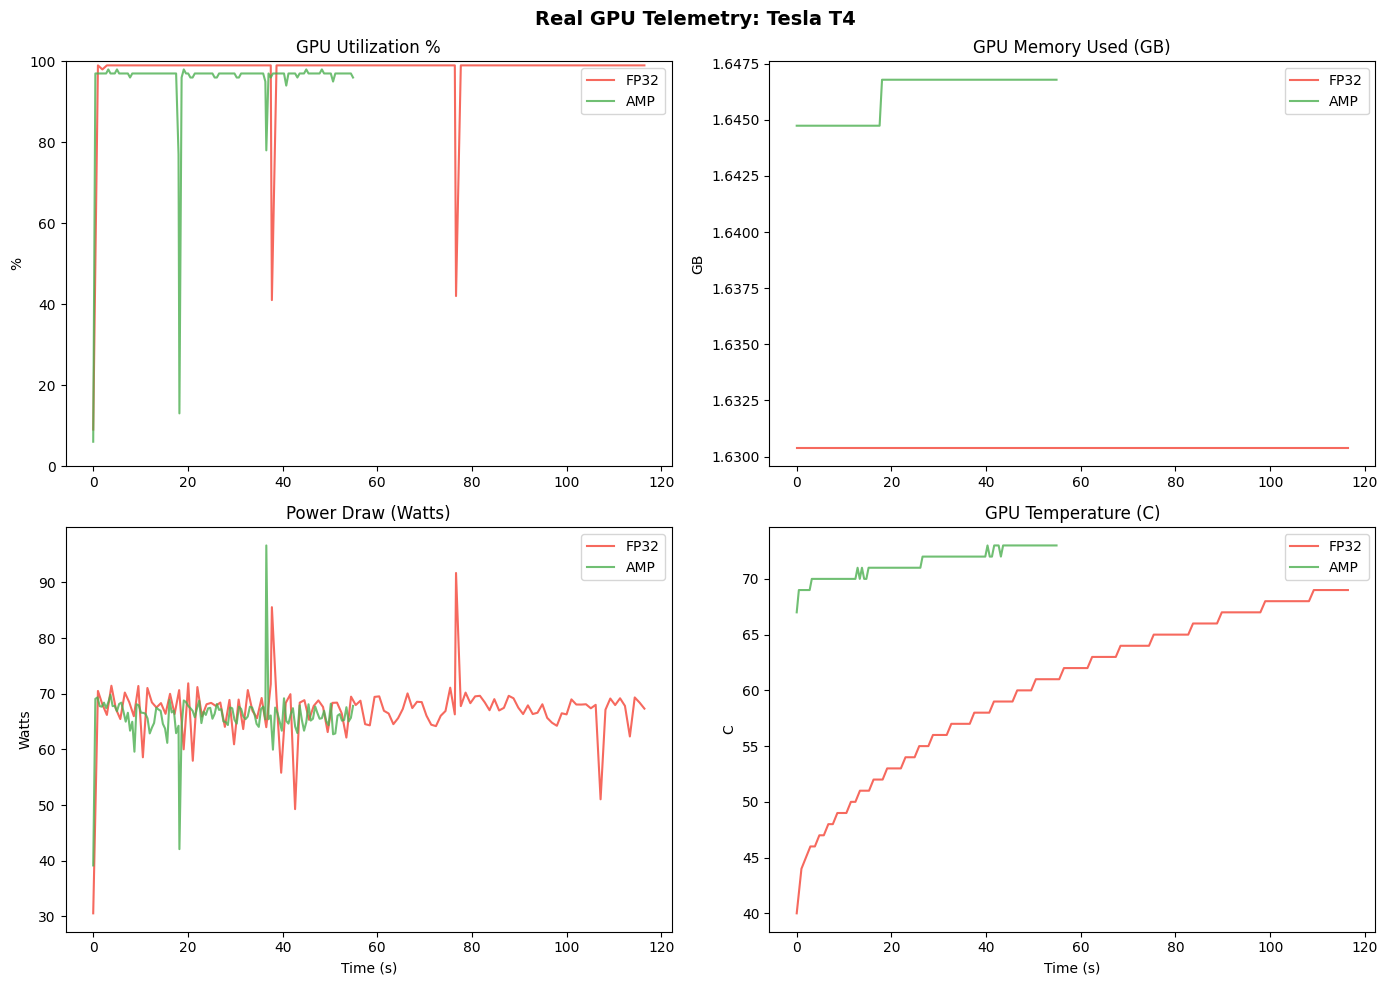

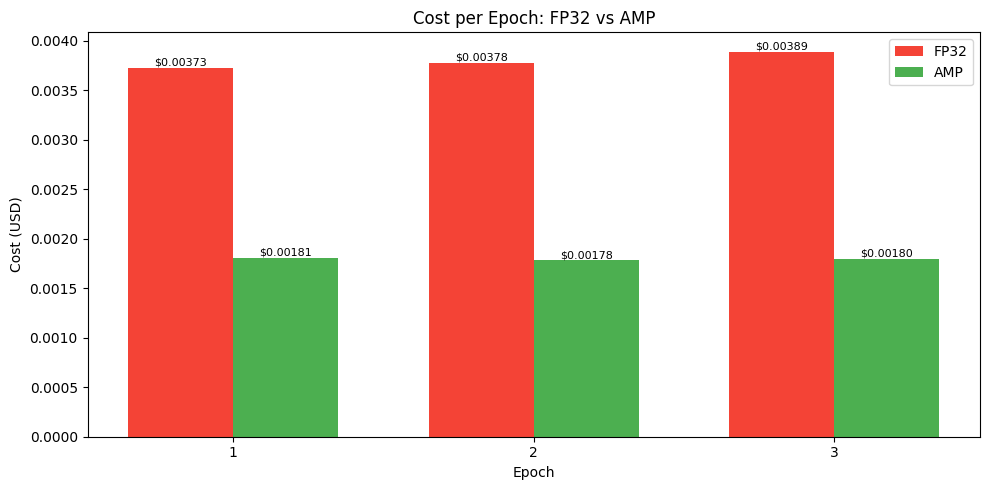


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [39]:
display_student_header('Cell 26: Real GPU Monitoring Visualization')
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

Multi-GPU scaling and cost table:


,gpu_count,gpu_type,speedup,training_time_hours,total_cost_usd,scaling_efficiency_pct,cost_per_speedup_usd,cost_delta_vs_1gpu_pct
0,1,A100,1.00x,2.00,$7.34,100.0%,$7.34,+0.0%
1,2,A100,1.80x,1.11,$8.16,90.0%,$4.53,+11.1%
2,4,A100,3.20x,0.62,$9.18,80.0%,$2.87,+25.0%
3,8,A100,5.60x,0.36,$10.49,70.0%,$1.87,+42.9%



Recommendations:
   Lowest cost: 1x A100 -> $7.34
   Fastest run: 8x A100 -> 0.36h
   Best cost/performance: 8x A100 -> $1.87/speedup


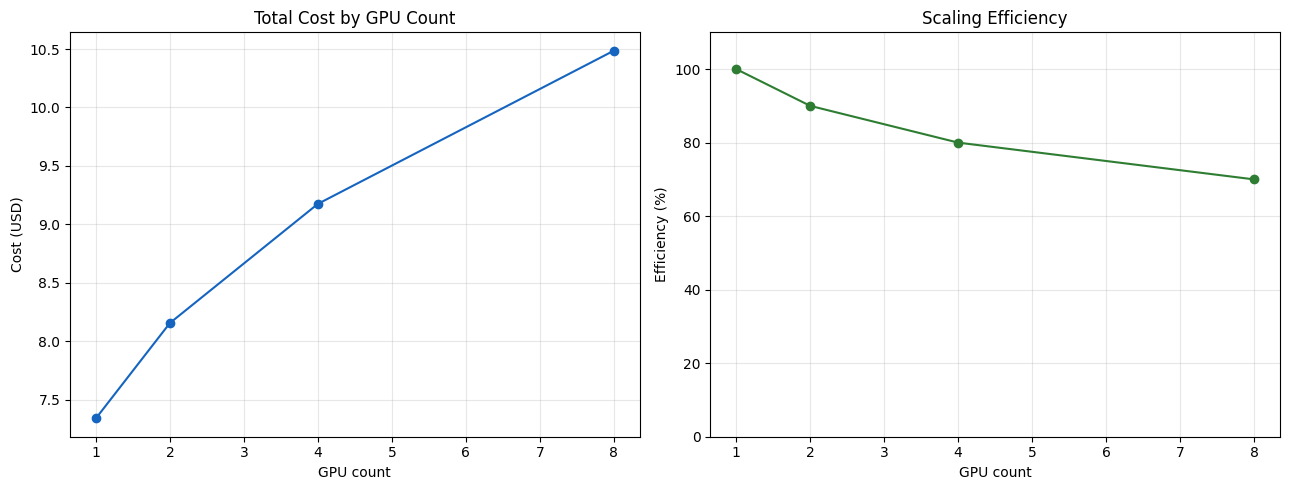

Chart saved: multi_gpu_scaling.png


In [28]:
display_student_header('Cell 27: Multi-GPU Cost Analysis')
# Cell 27: Multi-GPU Cost Analysis

print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

GPU_PRICING = globals().get("GPU_PRICING", {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81})


def default_speedup(gpu_count):
    defaults = {1: 1.0, 2: 1.8, 4: 3.2, 8: 5.6, 16: 9.6}
    if gpu_count in defaults:
        return defaults[gpu_count]
    return max(1.0, gpu_count ** 0.78)


def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """Analyze time, cost, speedup, and efficiency for multi-GPU training."""
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown gpu_type={gpu_type}. Available: {sorted(GPU_PRICING)}")

    price_per_hour = GPU_PRICING[gpu_type]
    rows = []
    for count in gpu_counts:
        speedup = (scaling_factors or {}).get(count, default_speedup(count))
        training_time = base_time_hours / speedup
        total_cost = training_time * price_per_hour * count
        baseline_cost = base_time_hours * price_per_hour
        efficiency_pct = (speedup / count) * 100
        cost_per_speedup = total_cost / speedup
        cost_delta_pct = ((total_cost - baseline_cost) / baseline_cost) * 100 if baseline_cost else 0
        rows.append({
            "gpu_count": count,
            "gpu_type": gpu_type,
            "speedup": speedup,
            "training_time_hours": training_time,
            "total_cost_usd": total_cost,
            "scaling_efficiency_pct": efficiency_pct,
            "cost_per_speedup_usd": cost_per_speedup,
            "cost_delta_vs_1gpu_pct": cost_delta_pct,
        })

    df = pd.DataFrame(rows)
    optimal_cost = df.loc[df["total_cost_usd"].idxmin()].to_dict()
    optimal_speed = df.loc[df["training_time_hours"].idxmin()].to_dict()
    balanced = df.loc[df["cost_per_speedup_usd"].idxmin()].to_dict()
    return {
        "gpu_type": gpu_type,
        "base_time_hours": base_time_hours,
        "price_per_hour": price_per_hour,
        "table": df,
        "optimal_cost": optimal_cost,
        "optimal_speed": optimal_speed,
        "balanced_choice": balanced,
    }


base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]
multi_gpu_analysis = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)
multi_gpu_df = multi_gpu_analysis["table"]

print("\nMulti-GPU scaling and cost table:")
display(multi_gpu_df.style.format({
    "speedup": "{:.2f}x",
    "training_time_hours": "{:.2f}",
    "total_cost_usd": "${:.2f}",
    "scaling_efficiency_pct": "{:.1f}%",
    "cost_per_speedup_usd": "${:.2f}",
    "cost_delta_vs_1gpu_pct": "{:+.1f}%",
}))

print("\nRecommendations:")
print(f"   Lowest cost: {int(multi_gpu_analysis['optimal_cost']['gpu_count'])}x {multi_gpu_analysis['gpu_type']} -> ${multi_gpu_analysis['optimal_cost']['total_cost_usd']:.2f}")
print(f"   Fastest run: {int(multi_gpu_analysis['optimal_speed']['gpu_count'])}x {multi_gpu_analysis['gpu_type']} -> {multi_gpu_analysis['optimal_speed']['training_time_hours']:.2f}h")
print(f"   Best cost/performance: {int(multi_gpu_analysis['balanced_choice']['gpu_count'])}x {multi_gpu_analysis['gpu_type']} -> ${multi_gpu_analysis['balanced_choice']['cost_per_speedup_usd']:.2f}/speedup")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(multi_gpu_df["gpu_count"], multi_gpu_df["total_cost_usd"], marker="o", color="#1565C0")
axes[0].set_title("Total Cost by GPU Count")
axes[0].set_xlabel("GPU count")
axes[0].set_ylabel("Cost (USD)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(multi_gpu_df["gpu_count"], multi_gpu_df["scaling_efficiency_pct"], marker="o", color="#2E7D32")
axes[1].set_title("Scaling Efficiency")
axes[1].set_xlabel("GPU count")
axes[1].set_ylabel("Efficiency (%)")
axes[1].set_ylim(0, 110)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("multi_gpu_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: multi_gpu_scaling.png")

EXERCISE 8.5.2: Project Cost Forecasting

Phase-by-phase forecast:


,phase,gpu_type,gpu_count,duration_hours,base_cost_usd,uncertainty_pct,low_cost_usd,high_cost_usd
0,Data Preparation,T4,1,40.0,$14.00,15%,$11.90,$16.10
1,Model Training,A100,4,120.0,$1761.60,25%,$1321.20,$2202.00
2,Hyperparameter Tuning,A100,8,60.0,$1761.60,30%,$1233.12,$2290.08
3,Model Evaluation,T4,2,20.0,$14.00,10%,$12.60,$15.40



Forecast summary:
   Base total:        $3551.20
   Contingency:       $710.24 (20%)
   Expected total:    $4261.44
   95% interval:      $2913.09 - $5609.79
   Best/Worst case:   $2578.82 - $5233.82


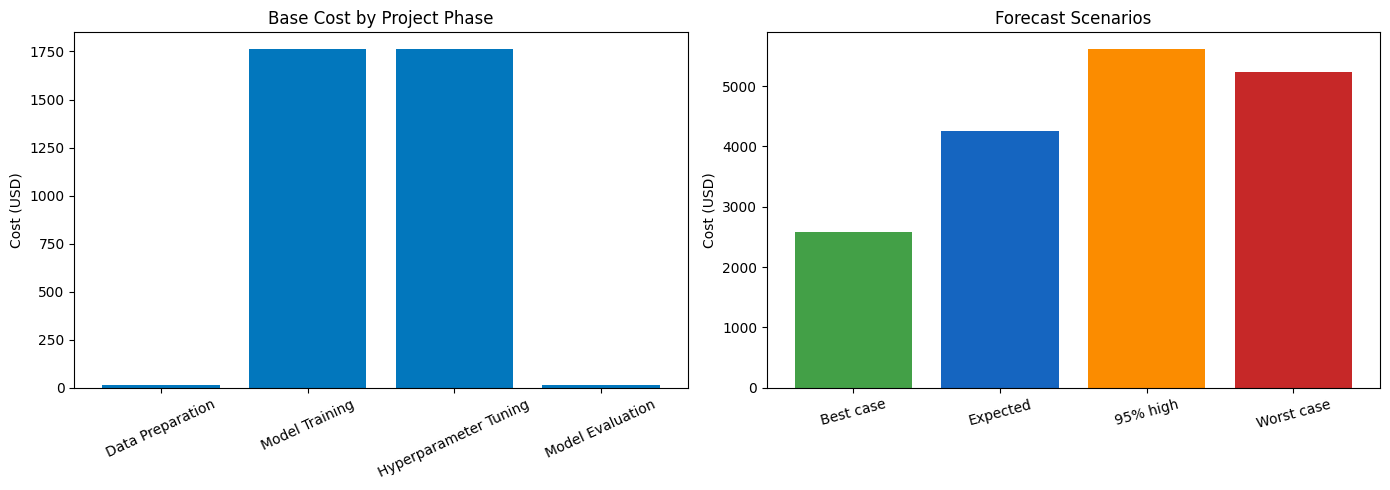

Chart saved: project_forecast.png


In [29]:
display_student_header('Cell 28: Project Cost Forecasting')
# Cell 28: Project Cost Forecasting

print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)


def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """Forecast multi-phase GPU project cost with uncertainty and contingency."""
    z_by_conf = {0.80: 1.28, 0.90: 1.64, 0.95: 1.96, 0.99: 2.58}
    z = z_by_conf.get(round(confidence_level, 2), 1.96)
    rows = []
    variance = 0.0

    for phase in phases:
        price = GPU_PRICING[phase["gpu_type"]]
        base_cost = phase["duration_hours"] * phase["gpu_count"] * price
        uncertainty_pct = phase.get("uncertainty_pct", 0.20)
        uncertainty_usd = base_cost * uncertainty_pct
        variance += uncertainty_usd ** 2
        rows.append({
            "phase": phase["name"],
            "gpu_type": phase["gpu_type"],
            "gpu_count": phase["gpu_count"],
            "duration_hours": phase["duration_hours"],
            "base_cost_usd": base_cost,
            "uncertainty_pct": uncertainty_pct * 100,
            "low_cost_usd": max(0, base_cost - uncertainty_usd),
            "high_cost_usd": base_cost + uncertainty_usd,
        })

    phase_df = pd.DataFrame(rows)
    base_total = phase_df["base_cost_usd"].sum()
    contingency = base_total * (contingency_pct / 100)
    expected_total = base_total + contingency
    combined_std_proxy = variance ** 0.5
    ci_low = max(0, expected_total - z * combined_std_proxy)
    ci_high = expected_total + z * combined_std_proxy

    return {
        "phases": phase_df,
        "base_total_usd": base_total,
        "contingency_pct": contingency_pct,
        "contingency_usd": contingency,
        "expected_total_usd": expected_total,
        "confidence_level": confidence_level,
        "confidence_low_usd": ci_low,
        "confidence_high_usd": ci_high,
        "best_case_usd": phase_df["low_cost_usd"].sum(),
        "worst_case_usd": phase_df["high_cost_usd"].sum() + contingency,
    }


example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
forecast_df = project_forecast["phases"]

print("\nPhase-by-phase forecast:")
display(forecast_df.style.format({
    "duration_hours": "{:.1f}",
    "base_cost_usd": "${:.2f}",
    "uncertainty_pct": "{:.0f}%",
    "low_cost_usd": "${:.2f}",
    "high_cost_usd": "${:.2f}",
}))

print("\nForecast summary:")
print(f"   Base total:        ${project_forecast['base_total_usd']:.2f}")
print(f"   Contingency:       ${project_forecast['contingency_usd']:.2f} ({project_forecast['contingency_pct']}%)")
print(f"   Expected total:    ${project_forecast['expected_total_usd']:.2f}")
print(f"   95% interval:      ${project_forecast['confidence_low_usd']:.2f} - ${project_forecast['confidence_high_usd']:.2f}")
print(f"   Best/Worst case:   ${project_forecast['best_case_usd']:.2f} - ${project_forecast['worst_case_usd']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(forecast_df["phase"], forecast_df["base_cost_usd"], color="#0277BD")
axes[0].set_title("Base Cost by Project Phase")
axes[0].set_ylabel("Cost (USD)")
axes[0].tick_params(axis='x', rotation=25)

scenario_names = ["Best case", "Expected", "95% high", "Worst case"]
scenario_values = [
    project_forecast["best_case_usd"],
    project_forecast["expected_total_usd"],
    project_forecast["confidence_high_usd"],
    project_forecast["worst_case_usd"],
]
axes[1].bar(scenario_names, scenario_values, color=["#43A047", "#1565C0", "#FB8C00", "#C62828"])
axes[1].set_title("Forecast Scenarios")
axes[1].set_ylabel("Cost (USD)")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("project_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: project_forecast.png")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Baseline cost: $1468.00

Ranked optimization opportunities:


,rank,strategy,savings_pct,potential_savings_usd,implementation_effort,risk_level,priority_score
0,1,Switch to Mixed Precision (AMP),25.0%,$367.00,LOW,LOW,0.250
1,2,Optimize Batch Size,15.0%,$220.20,LOW,LOW,0.150
2,3,Implement Early Stopping,20.0%,$293.60,MEDIUM,LOW,0.100
3,4,Use Spot Instances,60.0%,$880.80,MEDIUM,HIGH,0.100
4,5,Switch to More Efficient GPU Type,40.0%,$587.20,HIGH,MEDIUM,0.067



Cumulative roadmap:


,rank,strategy,incremental_savings_usd,remaining_cost_usd,cumulative_savings_usd,cumulative_savings_pct
0,1,Switch to Mixed Precision (AMP),$367.00,$1101.00,$367.00,25.0%
1,2,Optimize Batch Size,$165.15,$935.85,$532.15,36.2%
2,3,Implement Early Stopping,$187.17,$748.68,$719.32,49.0%
3,4,Use Spot Instances,$449.21,$299.47,$1168.53,79.6%
4,5,Switch to More Efficient GPU Type,$119.79,$179.68,$1288.32,87.8%



Optimization summary:
   Final cost after roadmap: $179.68
   Total savings:            $1288.32 (87.8%)


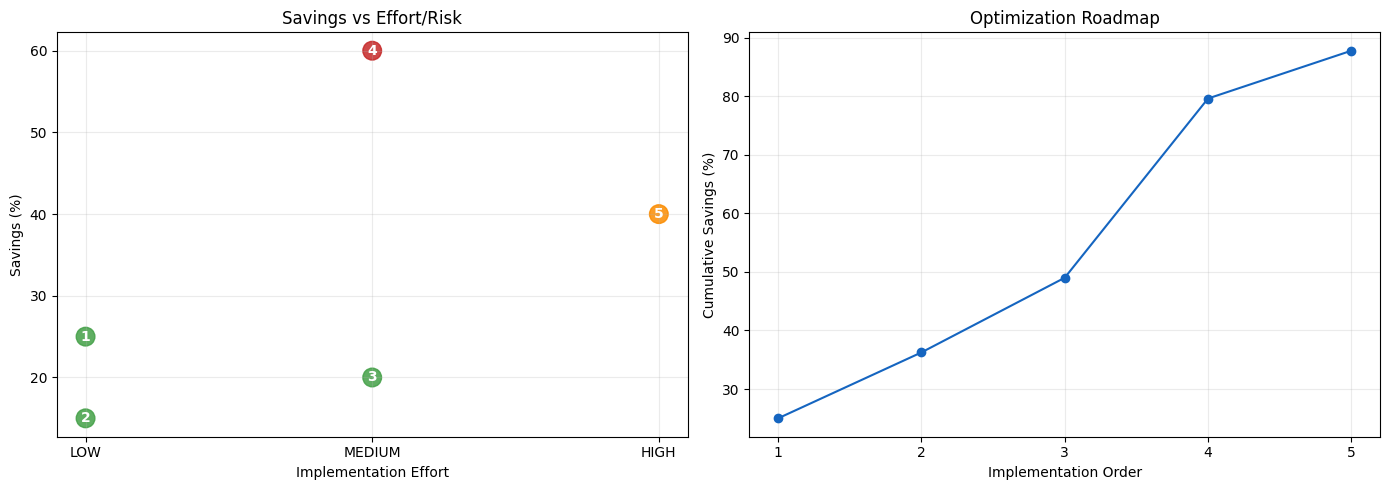

Chart saved: optimization_roadmap.png


In [30]:
display_student_header('Cell 29: Optimization Opportunity Analysis')
# Cell 29: Optimization Opportunity Analysis

print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)


def analyze_optimization_opportunities(current_config, optimization_strategies):
    """Analyze and prioritize optimization strategies by savings, effort, and risk."""
    effort_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    gpu_type = current_config["gpu_type"]
    baseline_cost = (current_config["duration_hours"] * current_config["gpu_count"] * GPU_PRICING[gpu_type])

    rows = []
    for strategy in optimization_strategies:
        effort = effort_score[strategy["implementation_effort"]]
        risk = risk_score[strategy["risk_level"]]
        savings_pct = strategy["savings_pct"]
        potential_savings = baseline_cost * savings_pct
        priority_score = savings_pct / (effort * risk)
        rows.append({
            "strategy": strategy["name"],
            "savings_pct": savings_pct * 100,
            "potential_savings_usd": potential_savings,
            "implementation_effort": strategy["implementation_effort"],
            "risk_level": strategy["risk_level"],
            "effort_score": effort,
            "risk_score": risk,
            "priority_score": priority_score,
            "dependencies": ", ".join(strategy.get("dependencies", [])) or "None",
        })

    df = pd.DataFrame(rows).sort_values(
        ["priority_score", "potential_savings_usd"], ascending=[False, False]
    ).reset_index(drop=True)
    df.insert(0, "rank", range(1, len(df) + 1))

    remaining_cost = baseline_cost
    cumulative_rows = []
    for _, row in df.iterrows():
        incremental_savings = remaining_cost * (row["savings_pct"] / 100)
        remaining_cost -= incremental_savings
        cumulative_rows.append({
            "rank": int(row["rank"]),
            "strategy": row["strategy"],
            "incremental_savings_usd": incremental_savings,
            "remaining_cost_usd": remaining_cost,
            "cumulative_savings_usd": baseline_cost - remaining_cost,
            "cumulative_savings_pct": ((baseline_cost - remaining_cost) / baseline_cost) * 100,
        })

    roadmap = pd.DataFrame(cumulative_rows)
    return {
        "baseline_cost_usd": baseline_cost,
        "recommendations": df,
        "roadmap": roadmap,
        "final_cost_usd": remaining_cost,
        "total_savings_usd": baseline_cost - remaining_cost,
        "total_savings_pct": ((baseline_cost - remaining_cost) / baseline_cost) * 100,
    }


example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)
recommendations_df = optimization_recommendations["recommendations"]
roadmap_df = optimization_recommendations["roadmap"]

print(f"\nBaseline cost: ${optimization_recommendations['baseline_cost_usd']:.2f}")
print("\nRanked optimization opportunities:")
display(recommendations_df[[
    "rank", "strategy", "savings_pct", "potential_savings_usd", "implementation_effort", "risk_level", "priority_score"
]].style.format({
    "savings_pct": "{:.1f}%",
    "potential_savings_usd": "${:.2f}",
    "priority_score": "{:.3f}",
}))

print("\nCumulative roadmap:")
display(roadmap_df.style.format({
    "incremental_savings_usd": "${:.2f}",
    "remaining_cost_usd": "${:.2f}",
    "cumulative_savings_usd": "${:.2f}",
    "cumulative_savings_pct": "{:.1f}%",
}))

print("\nOptimization summary:")
print(f"   Final cost after roadmap: ${optimization_recommendations['final_cost_usd']:.2f}")
print(f"   Total savings:            ${optimization_recommendations['total_savings_usd']:.2f} ({optimization_recommendations['total_savings_pct']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = recommendations_df["risk_level"].map({"LOW": "#43A047", "MEDIUM": "#FB8C00", "HIGH": "#C62828"})
axes[0].scatter(recommendations_df["effort_score"], recommendations_df["savings_pct"], s=180, c=colors, alpha=0.85)
for _, row in recommendations_df.iterrows():
    axes[0].annotate(str(int(row["rank"])), (row["effort_score"], row["savings_pct"]), ha="center", va="center", color="white", weight="bold")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["LOW", "MEDIUM", "HIGH"])
axes[0].set_xlabel("Implementation Effort")
axes[0].set_ylabel("Savings (%)")
axes[0].set_title("Savings vs Effort/Risk")
axes[0].grid(True, alpha=0.25)

axes[1].plot(roadmap_df["rank"], roadmap_df["cumulative_savings_pct"], marker="o", color="#1565C0")
axes[1].set_xticks(roadmap_df["rank"])
axes[1].set_xlabel("Implementation Order")
axes[1].set_ylabel("Cumulative Savings (%)")
axes[1].set_title("Optimization Roadmap")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("optimization_roadmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: optimization_roadmap.png")

EXERCISE 8.5.4: Integrated Cost Dashboard


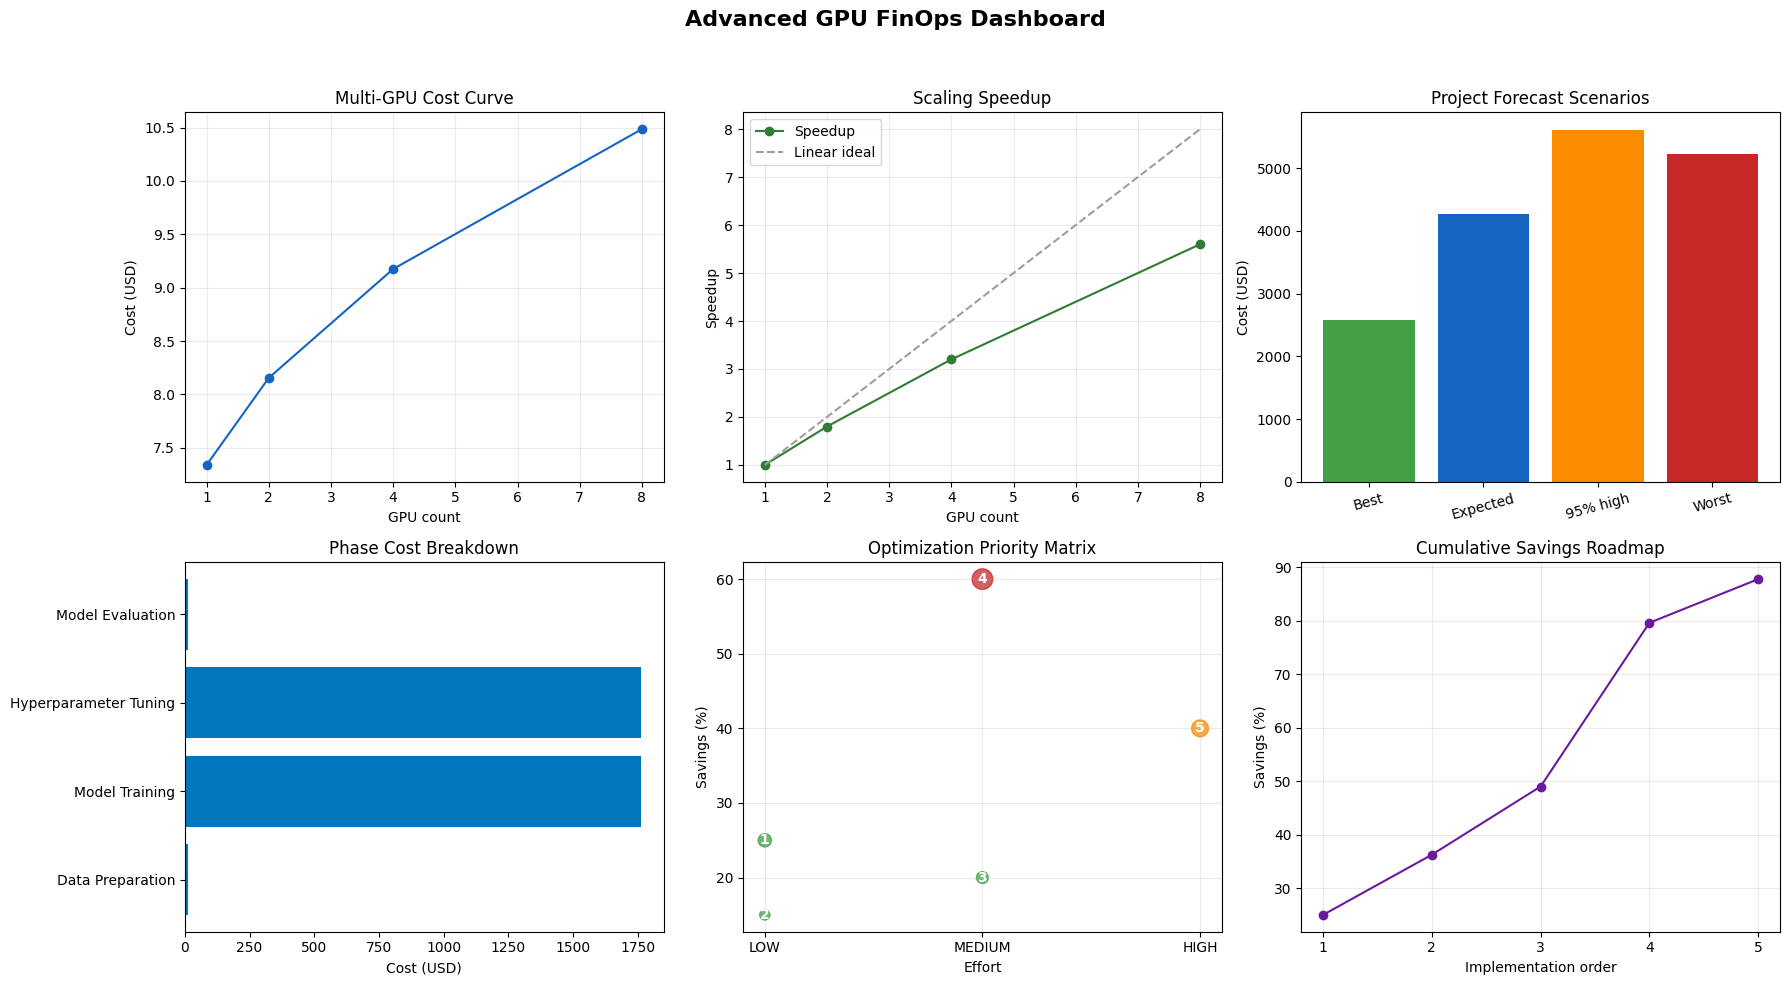

Dashboard saved: advanced_finops_dashboard.png


In [31]:
display_student_header('Cell 30: Integrated Cost Dashboard')
# Cell 30: Integrated Cost Dashboard

print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)


def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """Create a 6-panel dashboard combining advanced FinOps analyses."""
    mg = multi_gpu_analysis["table"]
    pf = project_forecast["phases"]
    recs = optimization_recommendations["recommendations"]
    roadmap = optimization_recommendations["roadmap"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold")

    ax = axes[0, 0]
    ax.plot(mg["gpu_count"], mg["total_cost_usd"], marker="o", color="#1565C0")
    ax.set_title("Multi-GPU Cost Curve")
    ax.set_xlabel("GPU count")
    ax.set_ylabel("Cost (USD)")
    ax.grid(True, alpha=0.25)

    ax = axes[0, 1]
    ax.plot(mg["gpu_count"], mg["speedup"], marker="o", label="Speedup", color="#2E7D32")
    ax.plot(mg["gpu_count"], mg["gpu_count"], linestyle="--", label="Linear ideal", color="#9E9E9E")
    ax.set_title("Scaling Speedup")
    ax.set_xlabel("GPU count")
    ax.set_ylabel("Speedup")
    ax.legend()
    ax.grid(True, alpha=0.25)

    ax = axes[0, 2]
    labels = ["Best", "Expected", "95% high", "Worst"]
    values = [
        project_forecast["best_case_usd"],
        project_forecast["expected_total_usd"],
        project_forecast["confidence_high_usd"],
        project_forecast["worst_case_usd"],
    ]
    ax.bar(labels, values, color=["#43A047", "#1565C0", "#FB8C00", "#C62828"])
    ax.set_title("Project Forecast Scenarios")
    ax.set_ylabel("Cost (USD)")
    ax.tick_params(axis='x', rotation=15)

    ax = axes[1, 0]
    ax.barh(pf["phase"], pf["base_cost_usd"], color="#0277BD")
    ax.set_title("Phase Cost Breakdown")
    ax.set_xlabel("Cost (USD)")

    ax = axes[1, 1]
    color_map = {"LOW": "#43A047", "MEDIUM": "#FB8C00", "HIGH": "#C62828"}
    ax.scatter(recs["effort_score"], recs["savings_pct"], s=recs["potential_savings_usd"] / 4, c=recs["risk_level"].map(color_map), alpha=0.75)
    for _, row in recs.iterrows():
        ax.annotate(str(int(row["rank"])), (row["effort_score"], row["savings_pct"]), ha="center", va="center", color="white", weight="bold")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["LOW", "MEDIUM", "HIGH"])
    ax.set_title("Optimization Priority Matrix")
    ax.set_xlabel("Effort")
    ax.set_ylabel("Savings (%)")
    ax.grid(True, alpha=0.25)

    ax = axes[1, 2]
    ax.plot(roadmap["rank"], roadmap["cumulative_savings_pct"], marker="o", color="#6A1B9A")
    ax.set_xticks(roadmap["rank"])
    ax.set_title("Cumulative Savings Roadmap")
    ax.set_xlabel("Implementation order")
    ax.set_ylabel("Savings (%)")
    ax.grid(True, alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


advanced_dashboard_fig = create_advanced_finops_dashboard(
    multi_gpu_analysis,
    project_forecast,
    optimization_recommendations,
)
advanced_dashboard_fig.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved: advanced_finops_dashboard.png")

In [32]:
display_student_header('Cell 31: Challenge Exercise - Cost Optimization Strategy Design')
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design

print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

req = challenge_scenario["requirements"]
constraints = challenge_scenario["constraints"]
baseline_cost = req["training_duration"] * req["gpu_count"] * GPU_PRICING[req["gpu_type"]]

print("CHALLENGE SCENARIO:")
print(f"   Project:  {challenge_scenario['project']}")
print(f"   Baseline: {req['gpu_count']}x {req['gpu_type']} for {req['training_duration']}h, {req['precision']}, {req['instance_type']}")
print(f"   Budget:   ${req['budget']:.2f}")
print(f"   Deadline: {constraints['deadline']}")
print(f"   Baseline cost: ${baseline_cost:.2f}")

challenge_gpu_counts = [1, 2, 4, 8]
challenge_multi_gpu = analyze_multi_gpu_cost(req["training_duration"], req["gpu_type"], challenge_gpu_counts)
challenge_mg_df = challenge_multi_gpu["table"]

# Deadline is 2 weeks, so all options under 336 hours are valid. Choose best cost/performance.
deadline_hours = 14 * 24
valid_options = challenge_mg_df[challenge_mg_df["training_time_hours"] <= deadline_hours]
selected_gpu = valid_options.loc[valid_options["cost_per_speedup_usd"].idxmin()].to_dict()

# Respect max preemption risk MEDIUM: avoid pure spot as primary recommendation.
selected_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Managed Spot for Retryable Jobs Only", "savings_pct": 0.25, "implementation_effort": "MEDIUM", "risk_level": "MEDIUM", "dependencies": []},
]

challenge_config = {
    "gpu_type": req["gpu_type"],
    "gpu_count": int(selected_gpu["gpu_count"]),
    "duration_hours": float(selected_gpu["training_time_hours"]),
    "precision": "FP32",
    "instance_type": "on-demand",
}
challenge_optimization = analyze_optimization_opportunities(challenge_config, selected_strategies)

optimized_compute_cost = challenge_optimization["final_cost_usd"]
challenge_phases = [
    {"name": "Final fine-tuning", "gpu_type": req["gpu_type"], "gpu_count": int(selected_gpu["gpu_count"]), "duration_hours": float(selected_gpu["training_time_hours"]), "uncertainty_pct": 0.20},
    {"name": "Evaluation and validation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 24, "uncertainty_pct": 0.15},
]
challenge_forecast = forecast_project_cost(challenge_phases, contingency_pct=15, confidence_level=0.95)
forecast_before_strategy = challenge_forecast["expected_total_usd"]
strategy_savings_pct = challenge_optimization["total_savings_pct"] / 100
final_expected_cost = forecast_before_strategy * (1 - strategy_savings_pct)
final_low = challenge_forecast["confidence_low_usd"] * (1 - strategy_savings_pct)
final_high = challenge_forecast["confidence_high_usd"] * (1 - strategy_savings_pct)
under_budget = final_expected_cost <= req["budget"]

print("\nMulti-GPU options:")
display(challenge_mg_df.style.format({
    "speedup": "{:.2f}x",
    "training_time_hours": "{:.1f}h",
    "total_cost_usd": "${:.2f}",
    "scaling_efficiency_pct": "{:.1f}%",
    "cost_per_speedup_usd": "${:.2f}",
    "cost_delta_vs_1gpu_pct": "{:+.1f}%",
}))

print("\nSelected compute plan:")
print(f"   GPU plan:       {int(selected_gpu['gpu_count'])}x {req['gpu_type']}")
print(f"   Runtime:        {selected_gpu['training_time_hours']:.1f}h <= {deadline_hours}h deadline")
print(f"   Raw GPU cost:   ${selected_gpu['total_cost_usd']:.2f}")

print("\nSelected optimization strategy:")
display(challenge_optimization["roadmap"].style.format({
    "incremental_savings_usd": "${:.2f}",
    "remaining_cost_usd": "${:.2f}",
    "cumulative_savings_usd": "${:.2f}",
    "cumulative_savings_pct": "{:.1f}%",
}))

print("\nFinal forecast:")
print(f"   Forecast before strategy: ${forecast_before_strategy:.2f}")
print(f"   Strategy savings:         {challenge_optimization['total_savings_pct']:.1f}%")
print(f"   Final expected cost:      ${final_expected_cost:.2f}")
print(f"   95% interval after opt:   ${final_low:.2f} - ${final_high:.2f}")
print(f"   Budget:                  ${req['budget']:.2f}")
print(f"   Verdict:                 {'UNDER BUDGET' if under_budget else 'OVER BUDGET'}")

print("\nJustification:")
print("   1. Use AMP first because it is low effort, low risk, and usually preserves model quality.")
print("   2. Optimize batch size before infrastructure changes because it improves utilization without adding preemption risk.")
print("   3. Add early stopping to cap runaway tuning/training cost while monitoring validation quality.")
print("   4. Use spot only for checkpointed/retryable jobs to satisfy the MEDIUM max preemption risk constraint.")
print("   5. Keep the selected GPU count within the 2-week deadline and verify the forecast against the $5000 budget.")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project:  Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h, FP32, on-demand
   Budget:   $5000.00
   Deadline: 2 weeks
   Baseline cost: $5872.00

Multi-GPU options:


,gpu_count,gpu_type,speedup,training_time_hours,total_cost_usd,scaling_efficiency_pct,cost_per_speedup_usd,cost_delta_vs_1gpu_pct
0,1,A100,1.00x,200.0h,$734.00,100.0%,$734.00,+0.0%
1,2,A100,1.80x,111.1h,$815.56,90.0%,$453.09,+11.1%
2,4,A100,3.20x,62.5h,$917.50,80.0%,$286.72,+25.0%
3,8,A100,5.60x,35.7h,$1048.57,70.0%,$187.24,+42.9%



Selected compute plan:
   GPU plan:       8x A100
   Runtime:        35.7h <= 336h deadline
   Raw GPU cost:   $1048.57

Selected optimization strategy:


,rank,strategy,incremental_savings_usd,remaining_cost_usd,cumulative_savings_usd,cumulative_savings_pct
0,1,Switch to Mixed Precision (AMP),$262.14,$786.43,$262.14,25.0%
1,2,Optimize Batch Size,$117.96,$668.46,$380.11,36.2%
2,3,Implement Early Stopping,$133.69,$534.77,$513.80,49.0%
3,4,Use Managed Spot for Retryable Jobs Only,$133.69,$401.08,$647.49,61.8%



Final forecast:
   Forecast before strategy: $1215.52
   Strategy savings:         61.8%
   Final expected cost:      $464.94
   95% interval after opt:   $307.71 - $622.16
   Budget:                  $5000.00
   Verdict:                 UNDER BUDGET

Justification:
   1. Use AMP first because it is low effort, low risk, and usually preserves model quality.
   2. Optimize batch size before infrastructure changes because it improves utilization without adding preemption risk.
   3. Add early stopping to cap runaway tuning/training cost while monitoring validation quality.
   4. Use spot only for checkpointed/retryable jobs to satisfy the MEDIUM max preemption risk constraint.
   5. Keep the selected GPU count within the 2-week deadline and verify the forecast against the $5000 budget.


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway